<a href="https://colab.research.google.com/github/salvadeharo10/k_brazos_DHBV/blob/main/3_bandit_experiments_ascensoGradiente.ipynb" target="_blank">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
</a>


**Asignatura**: Extensiones de Machine Learning, 2024/2025

**Alumnos**:<br>
- Salvador de Haro Orenes (salvadorde.haroo@um.es)
- Jose María Belmonte Martínez (josemaria.belmontem@um.es)
- Miguel Vidal García (miguel.vidalg@um.es)

**Máster de Inteligencia Artificial**

**Facultad de Informática**

![](https://www.um.es/image/layout_set_logo?img_id=175281&t=1726728636242)

**Universidad de Murcia**

![](https://www.um.es/o/um-lr-principal-um-home-theme/images/logo-um.png)


# Estudio comparativo de métodos de Ascenso del Gradiente en un problema de k-armed bandit

En este notebook se realiza un estudio para comparar el rendimiento de métodos de Ascenso del Gradiente en un problema de k-armed bandit. En particular, se compararan las políticas de los algoritmos `Softmax` y `Gradiente de Preferencias`. La comparación se realizará mediante las gráficas más relevantes que se discutieron en el notebook de estudio de algoritmos $\epsilon$-greedy. Esas gráficas son:
- Gráfica del porcentaje de selección promedio del brazo óptimo a lo largo del tiempo.
- Gráfica del rechazo promedio a lo largo del tiempo.

Para cada algoritmo se realizan 3 experimentos, que se diferencian por el tipo de distribución de probalidad asociada a los brazos del bandido. En particular:
1. Brazos con una distribución normal, con una media ($\mu$) aleatoria comprendida entre 1 y 10, y desviación típica ($\sigma$) 1.
2. Brazos con una distribución de probabilidad de Bernoulli.
3. Brazos con una distribución de probabilidad binomial.

En estos tres experimentos, cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan varios algoritmos `Softmax` con diferentes valores de $\tau$. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso se calculan los resultados promedio en esas 500 veces.

## Preparación del entorno


### Copiar el repositorio

In [1]:
# Clonar el repositorio en Google Colab
!git clone https://github.com/salvadeharo10/k_brazos_DHBV.git
%cd k_brazos_DHBV

# Confirmar clonación exitosa
print("✅ Repositorio clonado con éxito.")

Cloning into 'k_brazos_DHBV'...
remote: Enumerating objects: 507, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 507 (delta 83), reused 3 (delta 2), pack-reused 394 (from 2)
Receiving objects: 100% (507/507), 22.02 MiB | 8.20 MiB/s, done.
Resolving deltas: 100% (338/338), done.
/content/k_brazos_DHBV
✅ Repositorio clonado con éxito.


In [2]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('/content/k_brazos_DHBV/src')

# Verificar que se han añadido correctamente
print(sys.path)


['/content', '/env/python', '/usr/lib/python311.zip', '/usr/lib/python3.11', '/usr/lib/python3.11/lib-dynload', '', '/usr/local/lib/python3.11/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.11/dist-packages/IPython/extensions', '/root/.ipython', '/content/k_brazos_DHBV/src']


In [3]:
import numpy as np
from typing import List

from algorithms import Algorithm, Softmax, GradientBandit
from arms import ArmNormal, ArmBernoulli, ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

### Configuración de semilla para reproducibilidad de los experimentos

In [4]:
SEED = 1234
np.random.seed(SEED)

### Configuración de hiperparámetros de experimentos

A continuación, se defien los hiperparámetros de los experimentos, tales como el número de brazos del bandido, el número de pasos temporalesq que ejecutarán cada algoritmo y el número de veces que se repetirá el experimento.

In [5]:
# Parámetros de los experimentos
k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

## Experimentos Softmax



A continuación, se define una función denominada `run_experiment_softmax`, que se usará para la realización de los distintos experimentos del algoritmo `Softmax`.

En el método `select_arm()` de la clase `Softmax` (definida en el módulo */src/algorithms/softmax.py*) se implementa la política de selección de acciones (brazos) de este algoritmo. A cada acción se le asigna una probabilidad de selección con la siguiente fórmula:

$$ \pi_t(a) = \frac{e^{Q_t(a) / \tau}}{\sum_{b=1}^{k} e^{Q_t(b) / \tau}} $$

donde $\tau$ es un parámetro estrictamente positivo que regula el equilibrio explotación-exploración:
- Si $\tau$ es grande, las probabilidades son más uniformes (más exploración).
- Si $\tau$ es pequeño, la probabilidad se concentra en el mejor brazo (más explotación).

In [6]:
def run_experiment_softmax(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    """
    Realiza simulaciones de un problema k-arm bandit con diferentes estrategias.

    :param bandit: Instancia del entorno de bandit.
    :param algorithms: Lista de algoritmos a evaluar.
    :param steps: Número de iteraciones en cada simulación.
    :param runs: Número de veces que se repite la simulación para promediar resultados.
    """
    optimal_arm = bandit.optimal_arm  # Índice del mejor brazo.

    optimal_picks = np.zeros((len(algorithms), steps))  # Registro de elecciones óptimas.
    regret = np.zeros((runs, len(algorithms), steps))  # Registro de regret acumulado.

    for run in range(runs):
        simulation_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset()  # Restablecer valores del algoritmo antes de cada ejecución.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                selected_arm = algo.select_arm()
                reward = simulation_bandit.pull_arm(selected_arm)
                algo.update(selected_arm, reward)

                # Calcular regret instantáneo basado en la mejor recompensa esperada
                optimal_reward = simulation_bandit.get_expected_value(optimal_arm)
                selected_reward = simulation_bandit.get_expected_value(selected_arm)
                instant_regret = optimal_reward - selected_reward

                # Acumulación correcta del regret
                regret[run, idx, step] += instant_regret
                if step > 0:
                    regret[run, idx, step] += regret[run, idx, step - 1]

                # Registrar selecciones óptimas
                optimal_picks[idx, step] += (selected_arm == optimal_arm)

    # Promediar resultados sobre todas las simulaciones
    avg_regret = np.mean(regret, axis=0)  # Matriz 2D con promedios de regret
    optimal_picks /= runs
    optimal_picks *= 100  # Convertir en porcentaje


    return optimal_picks, avg_regret

### Softmax - Bandido con brazos de distribución normal

In [7]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k, seed = SEED)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k, tau = 0.5), Softmax(k, tau = 1), Softmax(k, tau = 5)]

# Ejecutar el experimento y obtener resultados
optimal_selections, regret = run_experiment_softmax(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmNormal(mu=2.72, sigma=1.0), ArmNormal(mu=3.45, sigma=1.0), ArmNormal(mu=4.94, sigma=1.0), ArmNormal(mu=3.49, sigma=1.0), ArmNormal(mu=6.6, sigma=1.0), ArmNormal(mu=8.07, sigma=1.0), ArmNormal(mu=8.02, sigma=1.0), ArmNormal(mu=8.22, sigma=1.0), ArmNormal(mu=9.62, sigma=1.0), ArmNormal(mu=8.88, sigma=1.0)
Optimal arm: 9 with expected reward=9.62


#### Visualización de resultados

##### Porcentaje de selección de brazo óptimo vs. Pasos de tiempo

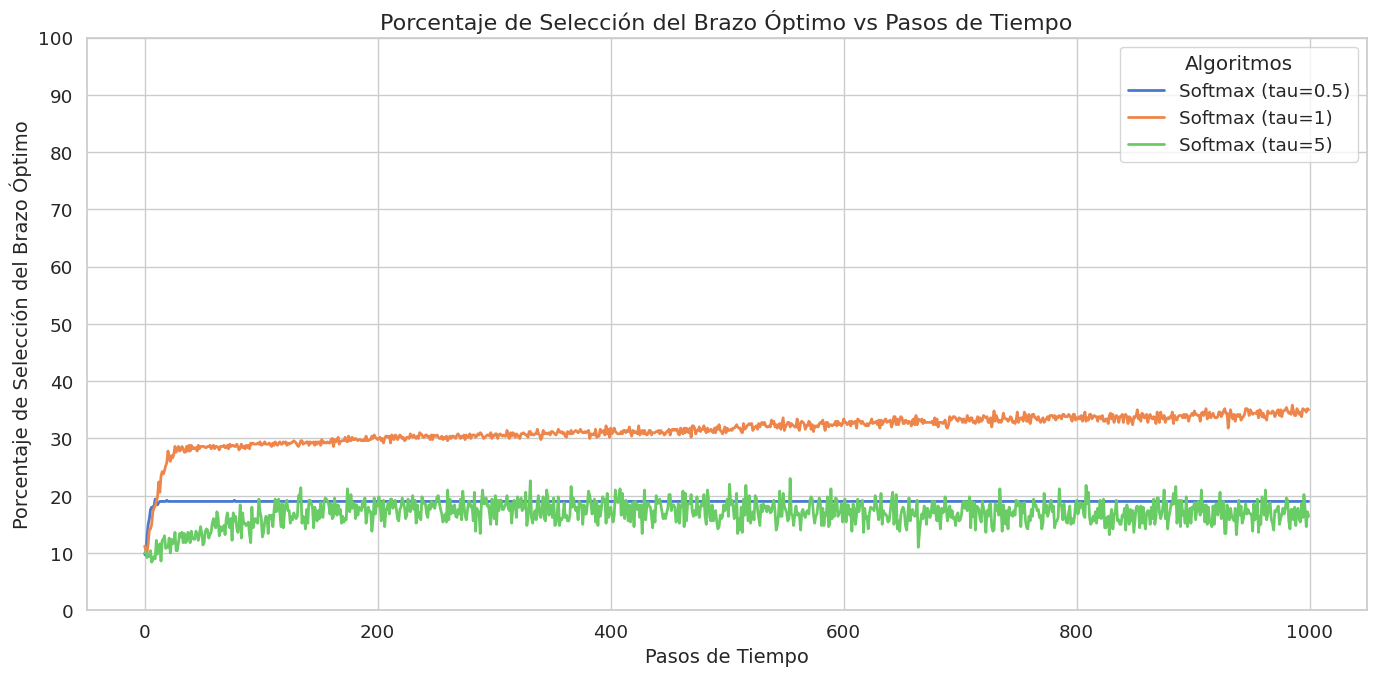

In [8]:
plot_optimal_selections(steps, optimal_selections, algorithms)

**Análisis**

El gráfico antior muestra el porcentaje de selección del brazo óptimo a lo largo del tiempo para diferentes valores del parámetro $\tau$ en el algoritmo Softmax. Se han promediado los resultados sobre 500 repeticiones del experimento.

- $\tau = 0.5$ (línea azul):
    - Se observa una selección estable en torno al 20%, lo que indica una preferencia moderada por el brazo óptimo.
    - Al tener un valor bajo de $\tau$, la política Softmax favorece más la explotación, pero aún permite algo de exploración.

- $\tau = 1$ (línea naranja):
    - La mejor selección del brazo óptimo (30-35%) se logra con $\tau = 1$.
    - Este valor parece proporcionar un buen equilibrio entre exploración y explotación.
    - Se observa una convergencia rápida en los primeros pasos del tiempo.

- $\tau = 5$ (línea verde):
    - La selección del brazo óptimo es la más baja (en torno al 15%) y fluctuante.
    - Con $\tau$ alto, la exploración es muy fuerte, lo que significa que el algoritmo sigue seleccionando brazos subóptimos con una alta probabilidad.
    - La selección del mejor brazo es casi aleatoria, lo que indica poca explotación de los mejores brazos.

---

##### Rechazo acumulado a lo largo del tiempo

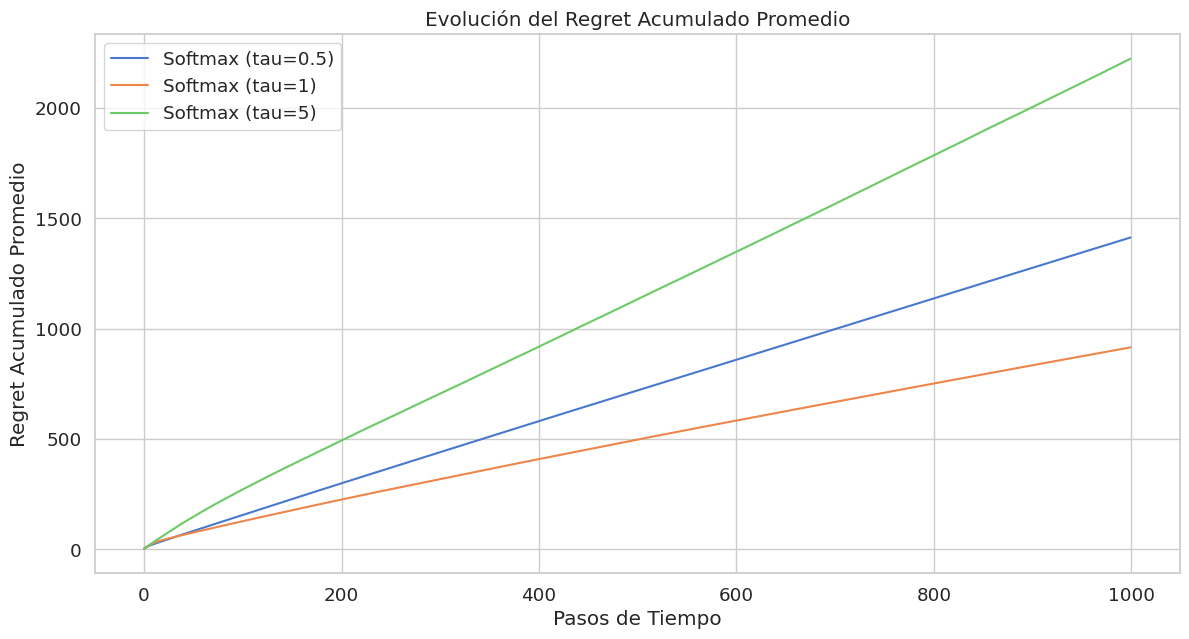

In [9]:
plot_regret(steps, regret, algorithms)

**Análisis**

El gráfico muestra la evolución del regret acumulado en función del tiempo para el algoritmo Softmax con distintos valores del parámetro $\tau$. Un menor regret indica un mejor desempeño del algoritmo.

- $\tau = 0.5$ (línea azul):
    - El regret inicial es alto, pero disminuye rápidamente y se estabiliza en torno a 1.5.
    - Al tener un valor bajo de $\tau$, la política Softmax favorece más la explotación, lo que evita exploración innecesaria de brazos subóptimos y reduce el regret a largo plazo.

- $\tau = 1$ (línea naranja):
    - Es el que alcanza el menor regret acumulado, tal y como era de esperar tras observar los porcentajes de selecció de brazo óptimo.
    - Este valor parece proporcionar un buen equilibrio entre exploración y explotación.
    - La curva desciende rápidamente en los primeros pasos y luego se estabiliza en el valor más bajo.

- $\tau = 5$ (línea verde):
    - Mantiene un regret elevado y fluctuante incluso después de muchas iteraciones.
    - Con $\tau$ alto, la exploración es muy fuerte, lo que significa que el algoritmo sigue seleccionando brazos subóptimos con una alta probabilidad.
    - Nunca converge completamente a explotar el mejor brazo, lo que explica la falta de disminución en el regret.

---

### Softmax - bandido de brazos con distribución de Bernoulli

In [10]:
# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k, seed = SEED)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k, tau = 0.5), Softmax(k, tau = 1), Softmax(k, tau = 5)]

# Ejecutar el experimento y obtener resultados
optimal_selections, regret = run_experiment_softmax(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.25), ArmBernoulli(p=0.6), ArmBernoulli(p=0.45), ArmBernoulli(p=0.72), ArmBernoulli(p=0.73), ArmBernoulli(p=0.32), ArmBernoulli(p=0.74), ArmBernoulli(p=0.87), ArmBernoulli(p=0.8), ArmBernoulli(p=0.39)
Optimal arm: 8 with expected reward=0.87


#### Visualización de resultados

En este experimento, se ha cambiado la distribución de recompensas del bandido multibrazo, utilizando una distribución de Bernoulli con una probabilidad $p$ de éxito aleatoria entre 0 y 1 para cada brazo.

##### Porcentaje de selección de brazo óptimo vs. Pasos de tiempo

El gráfico muestra el porcentaje de selección del brazo óptimo a lo largo del tiempo para distintos valores del parámetro $\tau$ en el algoritmo Softmax.

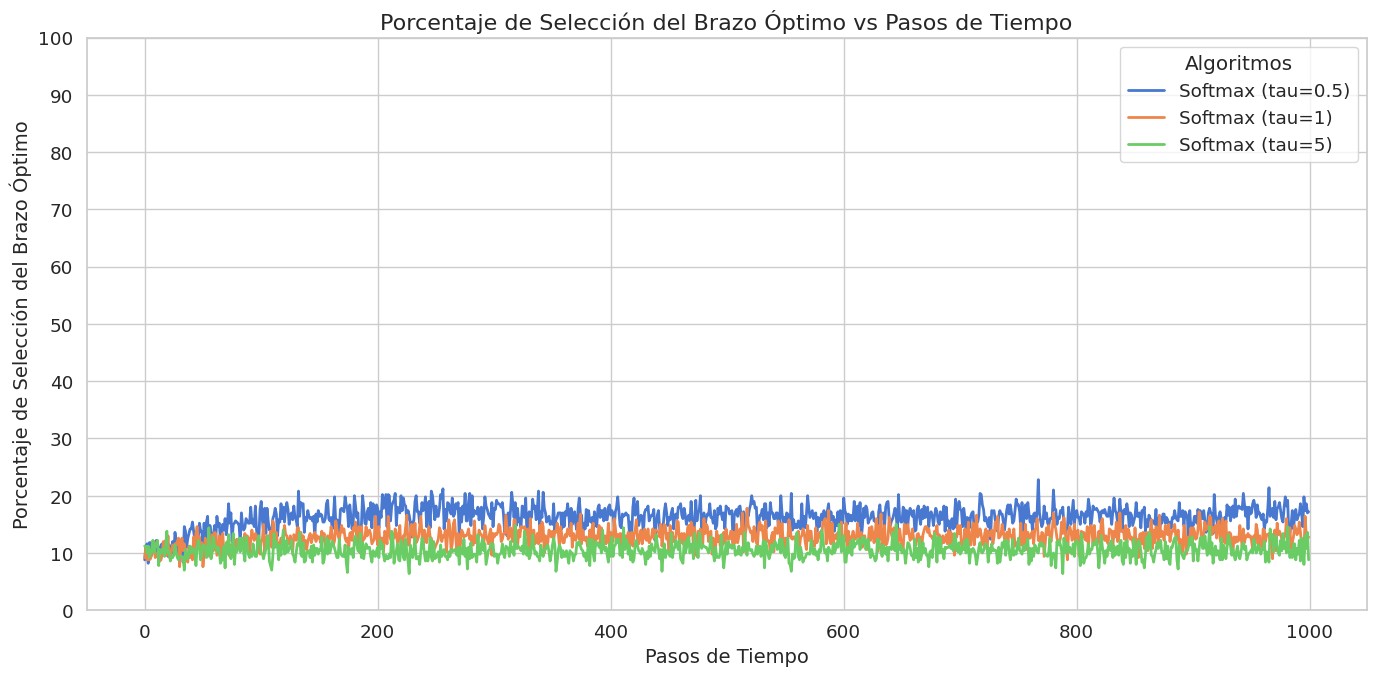

In [11]:
plot_optimal_selections(steps, optimal_selections, algorithms)

**Análisis**

A diferencia del caso anterior con distribuciones normales, ahora las recompensas son binarias (0 o 1), lo que impacta en la exploración y explotación del algoritmo.

- $\tau = 0.5$ (línea azul):
    - Presenta una mayor variabilidad en la selección del brazo óptimo.
    - Se mantiene en un promedio de alrededor del 15%, pero con oscilaciones significativas.
    - Un $\tau$ bajo favorece la explotación, pero en una distribución Bernoulli, esto puede ser un problema si el brazo óptimo no se descubre rápidamente.

- $\tau = 1$ (línea naranja):
    - Tiene un comportamiento más estable, pero con una selección del brazo óptimo similar a  $\tau = 0.5$.
    - No logra un aumento significativo en la frecuencia de selección del mejor brazo.

- $\tau = 5$ (línea verde):
    - Ofrece la menor frecuencia de selección del brazo óptimo
    - Como en la distribución normal, un $\tau$ alto causa demasiada exploración, lo que impide que el algoritmo se enfoque en el mejor brazo.


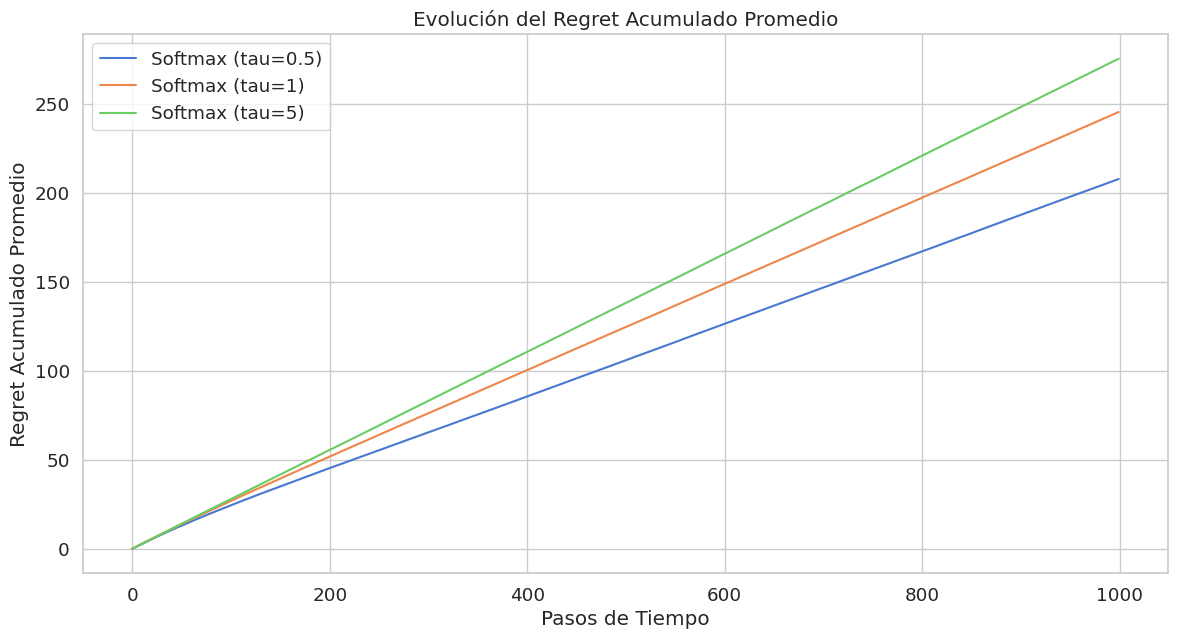

In [12]:
plot_regret(steps, regret, algorithms)

**Análisis**

El gráfico muestra la **evolución del regret acumulado** en función del tiempo para el algoritmo **Softmax**, evaluado con distintos valores del parámetro $\tau$.  
En este experimento, las recompensas de los brazos siguen una **distribución de Bernoulli** con $n = 10$ y una probabilidad $p$ aleatoria entre 0 y 1 para cada brazo.  

- $\tau = 0.5$ (línea azul):
    - Presenta el **menor regret** en comparación con los otros valores de $\tau$.  
    - La tendencia del regret es decreciente y estable en torno a **0.20 - 0.22**.  
    - Esto sugiere que, en este caso, una mayor **explotación** es beneficiosa para reducir el regret.

- $\tau = 1$ (línea naranja):
    - Mantiene un regret **moderado**, con valores cercanos a **0.24 - 0.25**.  
    - Aunque permite más exploración que $\tau = 0.5$, no logra reducir significativamente el regret.  
    - Esto puede deberse a la naturaleza discreta de las recompensas Bernoulli, donde explorar más no siempre es útil.

- $\tau = 5$ (línea verde):
    - El **peor desempeño**, con un regret elevado en torno a **0.28**.  
    - La alta exploración hace que el algoritmo continúe seleccionando brazos subóptimos incluso después de haber identificado el mejor brazo.  
    - Esto confirma que **una exploración excesiva perjudica el rendimiento** en este tipo de distribución de recompensas.

---

### Sofmax - Bandido de brazos con distribución binomial

In [13]:
# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k, n = 10, seed = SEED)) # Generar un bandido con k brazos de distribución binomial
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k, tau = 0.5), Softmax(k, tau = 1), Softmax(k, tau = 5)]

# Ejecutar el experimento y obtener resultados
optimal_selections, regret = run_experiment_softmax(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=10, p=0.25), ArmBinomial(n=10, p=0.6), ArmBinomial(n=10, p=0.45), ArmBinomial(n=10, p=0.72), ArmBinomial(n=10, p=0.73), ArmBinomial(n=10, p=0.32), ArmBinomial(n=10, p=0.74), ArmBinomial(n=10, p=0.87), ArmBinomial(n=10, p=0.8), ArmBinomial(n=10, p=0.39)
Optimal arm: 8 with expected reward=8.7


#### Visualización de resultados

En este experimento, se ha cambiado la distribución de recompensas del bandido multibrazo, utilizando una distribución Binomial de $n = 10$ (número de ensayos) y probabilidad $p$ de éxito aleatoria entre 0 y 1 para cada brazo.

###### Porcentaje de selección de brazo óptimo vs. Pasos de tiempo

El gráfico muestra el porcentaje de selección del brazo óptimo a lo largo del tiempo para distintos valores del parámetro $\tau$ en el algoritmo Softmax.

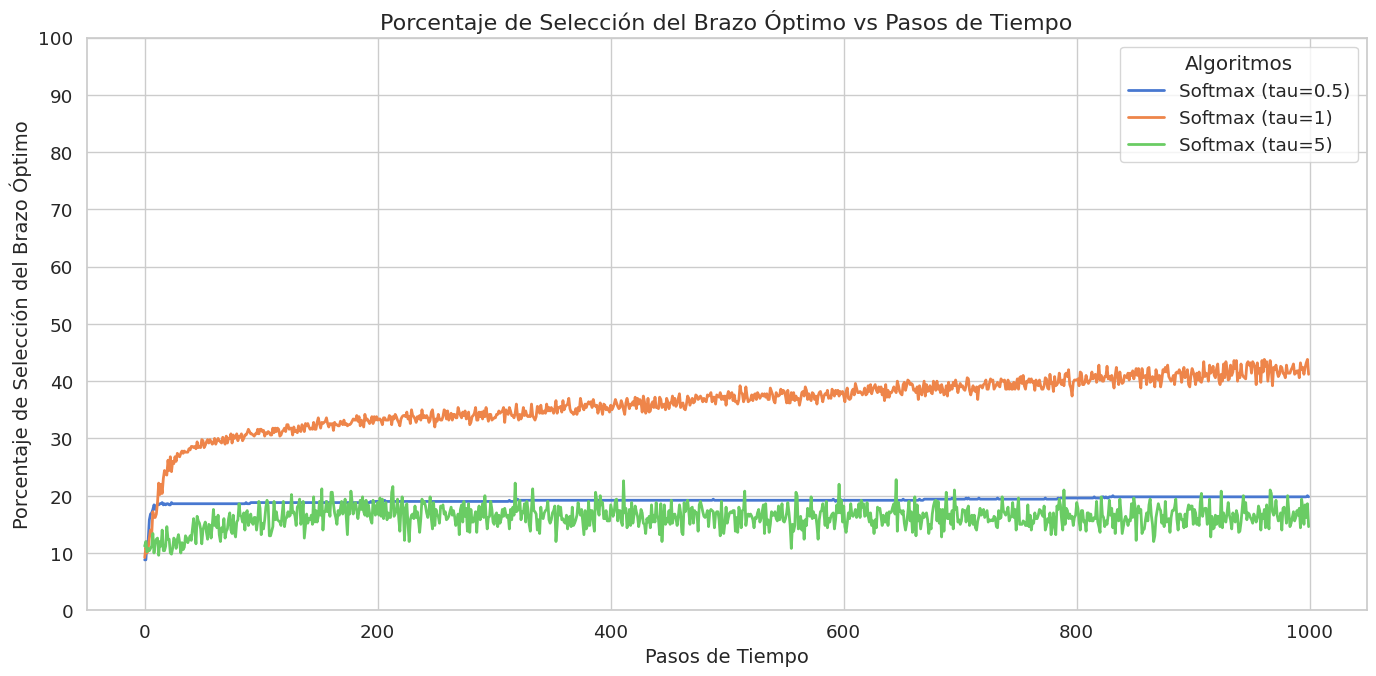

In [14]:
plot_optimal_selections(steps, optimal_selections, algorithms)

**Análisis**

El gráfico muestra el **porcentaje de selección del brazo óptimo** a lo largo del tiempo para distintos valores del parámetro $\tau$ en el algoritmo **Softmax**.

---
Al utilizar una distribución binomial, las recompensas pueden tomar valores discretos entre 0 y $n$, lo que introduce un comportamiento diferente en la exploración-explotación del algoritmo.

- **$\tau = 0.5$ (línea azul)**  
  - Se estabiliza alrededor del **20%** de selección del brazo óptimo.  
  - Un $\tau$ bajo favorece **más explotación**, pero al tratarse de una distribución binomial, la variabilidad en las recompensas puede hacer que el algoritmo no siempre identifique correctamente el mejor brazo.  

- **$\tau = 1$ (línea naranja)**  
  - Se observa el **mejor desempeño**, con una selección del brazo óptimo de aproximadamente **30-35%**.  
  - Encuentra un buen balance entre exploración y explotación, lo que le permite descubrir y preferir el mejor brazo con mayor frecuencia.  
  - La curva inicial muestra una rápida convergencia, lo que indica que el algoritmo está aprendiendo de manera efectiva.

- **$\tau = 5$ (línea verde)**  
  - Muestra el peor desempeño, con un porcentaje de selección del brazo óptimo de **~15% y con alta variabilidad**.  
  - La exploración excesiva impide que el algoritmo se concentre en el mejor brazo, lo que genera muchas selecciones subóptimas.  

---

#### Rechazo promedio a lo largo del tiempo

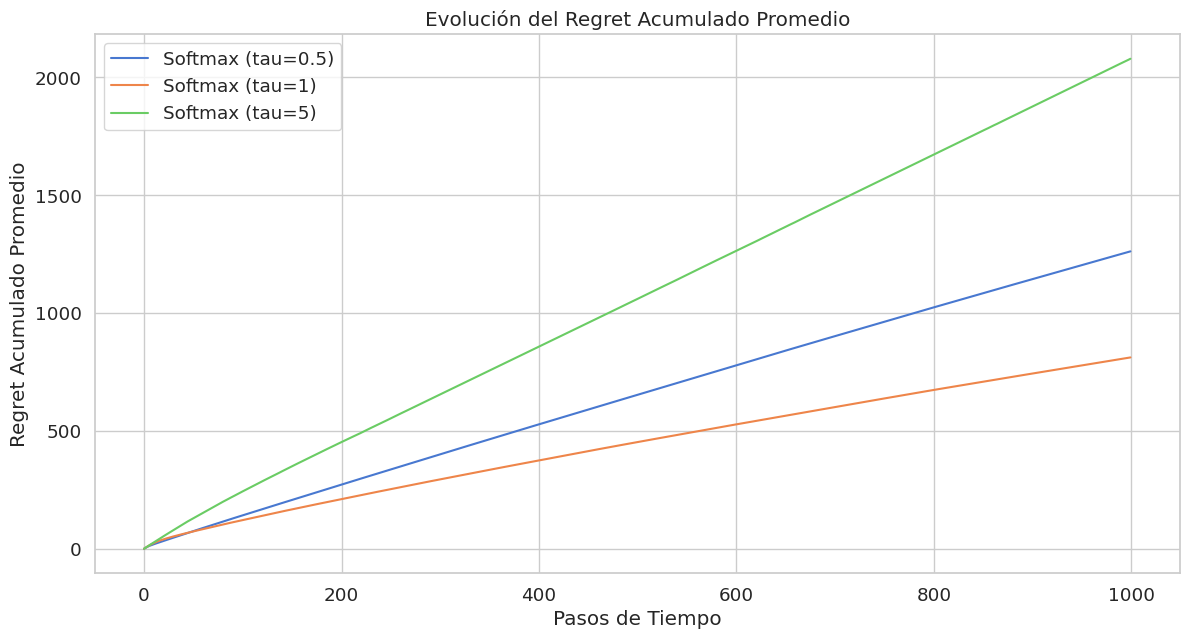

In [15]:
plot_regret(steps, regret, algorithms)

**Análisis**

El gráfico muestra la **evolución del regret acumulado** en función del tiempo para el algoritmo **Softmax** con distintos valores del parámetro de temperatura \( \tau \).  

---

- **$\tau = 0.5$ (línea azul)**  
  - Mantiene un regret **moderado (~1.3 - 1.4)**.  
  - La explotación temprana ayuda a reducir el regret, pero la falta de exploración impide alcanzar el mejor rendimiento posible.  

- **$\tau = 1$ (línea naranja)**  
  - Es el **mejor resultado**, con un regret acumulado cercano a **1.0** en las últimas etapas.  
  - La exploración inicial permite identificar rápidamente el mejor brazo, mientras que la explotación posterior ayuda a reducir el regret.  
  - Se observa una **rápida convergencia** en los primeros pasos del tiempo, lo que sugiere un aprendizaje eficiente.  

- **$\tau = 5$ (línea verde)**  
  - Tiene el **peor desempeño**, con un regret que oscila en torno a **2.0 - 2.2** y no disminuye significativamente.  
  - La exploración excesiva evita que el algoritmo se enfoque en el mejor brazo, lo que mantiene un regret elevado a lo largo del tiempo.  
  - Además, la alta variabilidad indica que el algoritmo no está aprendiendo de manera consistente.  

---

### Conclusiones finales

- **El parámetro $\tau$ en Softmax es crítico para el rendimiento del algoritmo.**  
- En **distribuciones normales y binomiales**, $\tau = 1$ ofrece el mejor balance** entre exploración y explotación.  
- En **distribuciones Bernoulli (binarias), valores más bajos de $\tau$ (ej. 0.5) son mejores**, ya que explorar demasiado no es útil cuando las recompensas son solo 0 o 1.  
- **$\tau = 5$ fue consistentemente ineficiente**, ya que forzó una exploración innecesaria que aumentó el regret y redujo la selección del mejor brazo.  
- **En problemas donde la recompensa tiene alta variabilidad, Softmax es una buena opción.**  
- **En recompensas discretas con menos variabilidad (Bernoulli), otros métodos como Epsilon-Greedy o Thompson Sampling pueden ser más efectivos.**  

En conclusión, **Softmax es un buen algoritmo para el problema del bandido multi-brazo, pero su rendimiento depende en gran medida de la distribución de recompensas y la elección adecuada del parámetro $\tau$**.

## Experimentos con Gradiente de Preferencias

A continuación, se define una función denominada `run_experiment_gradient`, que se usará para la realización de los distintos experimentos del algoritmo `Gradiente de Preferencias`.

En el método `select_arm()` de la clase `GradientBandit` (definida en el módulo */src/algorithms/gradiente_preferencias.py*) se implementa la política de selección de acciones (brazos) de este algoritmo. A cada acción se le asigna una probabilidad de selección con la siguiente fórmula (propuesta por Sutton y Barto en 2018):

$$ \pi_t(a) = \frac{e^{H_t(a)}}{\sum_{b=1}^{k} e^{H_t(b)}} $$

donde $H_t(a)$ es una preferencia numérica para cada acción $a$. A mayor preferencia (no recompensa), con más frecuencia se tomará la acción. Es decir, A diferencia de métodos como Epsilon-Greedy o Softmax clásico, que trabajan con recompensas promediadas, el Gradiente de Preferencias aprende una función de preferencia $H_t(a)$ para cada acción, la cual se ajusta mediante el Gradiente Estocástico.

Las preferencias no se calculan explícitamente a partir de las recompensas, sino que se ajustan dinámicamente en cada iteración del algoritmo.

Para cada acción $a$, las preferencias se actualizan de la siguiente manera:
$$ H_{t+1}(A_t) = H_t(A_t) + \alpha (R_t - \bar{R_t}) (1 - \pi_t(A_t)) $$

$$ H_{t+1}(a) = H_t(a) - \alpha (R_t - \bar{R_t}) \pi_t(a), \quad \text{para todo } a \neq A_t $$

donde:
- $H_t(a)$ es la preferencia de la acción $a$ en el instate $t$.
- $A_t$ es la acción seleccionada en el instante $t$.
- $R_t$ es la recompensa obtenida tras seleccionar $A_t$.
- $\bar{R_t}$ es la recompensa promedio hasta el momento.
- $\pi_t(a)$ es la probabilidad de seleccionar la acción $a$, calculada con Softmax.
- $\alpha$ es la tasa de aprendizaje.


In [16]:
def run_experiment_gradient(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    """
    Realiza simulaciones de un problema k-arm bandit con diferentes estrategias.

    :param bandit: Instancia del entorno de bandit.
    :param algorithms: Lista de algoritmos a evaluar.
    :param steps: Número de iteraciones en cada simulación.
    :param runs: Número de veces que se repite la simulación para promediar resultados.
    """
    optimal_arm = bandit.optimal_arm  # Índice del mejor brazo.

    optimal_picks = np.zeros((len(algorithms), steps))  # Registro de elecciones óptimas.
    regret = np.zeros((runs, len(algorithms), steps))  # Registro de regret acumulado.


    for run in range(runs):
        simulation_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset()  # Restablecer valores del algoritmo antes de cada ejecución.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                selected_arm = algo.select_arm()
                reward = simulation_bandit.pull_arm(selected_arm)
                algo.update(selected_arm, reward)

                # Calcular regret instantáneo basado en la mejor recompensa esperada
                optimal_reward = simulation_bandit.get_expected_value(optimal_arm)
                selected_reward = simulation_bandit.get_expected_value(selected_arm)
                instant_regret = optimal_reward - selected_reward

                # Acumulación correcta del regret
                regret[run, idx, step] += instant_regret
                if step > 0:
                    regret[run, idx, step] += regret[run, idx, step - 1]

                # Registrar selecciones óptimas
                optimal_picks[idx, step] += (selected_arm == optimal_arm)

    # Promediar resultados sobre todas las simulaciones
    avg_regret = np.mean(regret, axis=0)  # Matriz 2D con promedios de regret
    optimal_picks /= runs
    optimal_picks *= 100  # Convertir en porcentaje


    return optimal_picks, avg_regret

### Gradiente de preferencias - bandido con distribuciones normales

In [17]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k, seed = SEED)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [GradientBandit(k=k, alpha=0.1), GradientBandit(k=k, alpha=0.5), GradientBandit(k=k, alpha=1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
optimal_selections, regret = run_experiment_gradient(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmNormal(mu=2.72, sigma=1.0), ArmNormal(mu=3.45, sigma=1.0), ArmNormal(mu=4.94, sigma=1.0), ArmNormal(mu=3.49, sigma=1.0), ArmNormal(mu=6.6, sigma=1.0), ArmNormal(mu=8.07, sigma=1.0), ArmNormal(mu=8.02, sigma=1.0), ArmNormal(mu=8.22, sigma=1.0), ArmNormal(mu=9.62, sigma=1.0), ArmNormal(mu=8.88, sigma=1.0)
Optimal arm: 9 with expected reward=9.62


##### Visualización de resultados

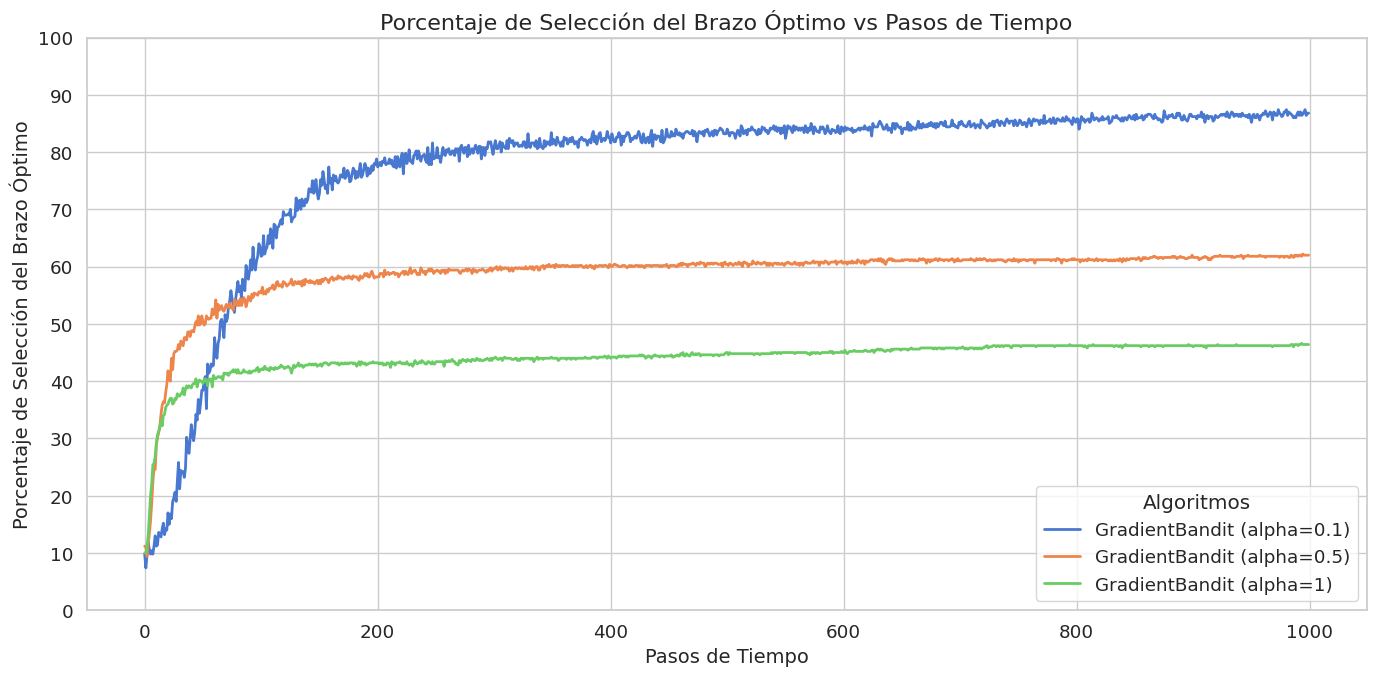

In [18]:
plot_optimal_selections(steps, optimal_selections, algorithms)

###### Porcentaje de selección óptima vs. Pasos de tiempo

El gráfico muestra el **porcentaje de selección del brazo óptimo** a lo largo del tiempo para el algoritmo de **Gradiente de Preferencias**, evaluado con diferentes valores de la tasa de aprendizaje $\alpha$.  
Cada curva representa el promedio de **500 repeticiones** del experimento, lo que permite observar tendencias generales en el rendimiento del algoritmo.

---

**Observaciones clave**
1. **El valor de $\alpha$ impacta significativamente el rendimiento del algoritmo**  
   - Con **$\alpha = 0.1$ (curva azul)**, el algoritmo aprende rápidamente y alcanza un **~90% de selección del brazo óptimo** en 1000 pasos.  
   - Con **$\alpha = 0.5$ (curva naranja)**, el rendimiento es **moderado**, estabilizándose cerca del **60%**.  
   - Con **$\alpha = 1.0$ (curva verde)**, el aprendizaje es más lento y se queda en torno al **50%**.  

2. **Valores más bajos de $\alpha$ favorecen una mejor convergencia**  
   - La curva azul ($\alpha = 0.1$) muestra una convergencia más estable y rápida, lo que sugiere que una tasa de aprendizaje moderada es beneficiosa.  
   - La curva verde ($\alpha = 1.0$) se estanca en valores más bajos, lo que indica que un $\alpha$ grande puede hacer que el algoritmo oscile y no aprenda correctamente.
---

**Conclusión:**
Si se busca un buen balance entre exploración y estabilidad, $\alpha \approx 0.1 - 0.2$ parece ser la mejor opción en este problema. Valores más altos de $\alpha$ favorecen una política más exploratoria, lo que supone un impedimento en el objetivo de maximizar la suma de las recompensas obtenidas.

###### Rechazo promedio vs. Pasos de tiempo

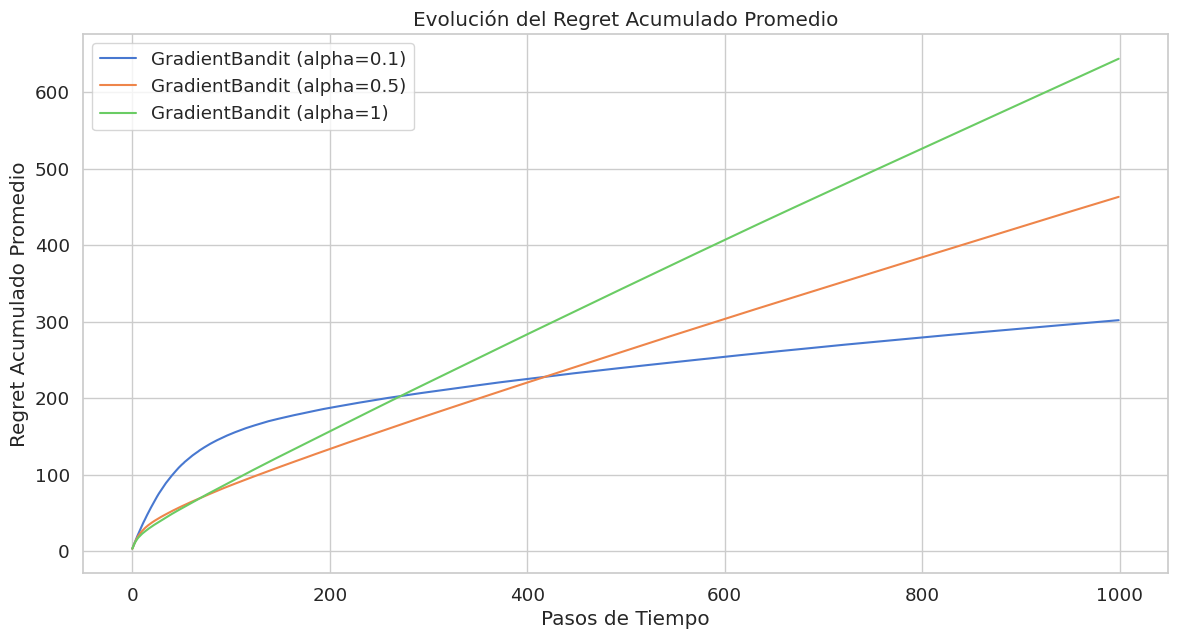

In [19]:
plot_regret(steps, regret, algorithms)

El gráfico muestra la **evolución del regret promedio** a lo largo del tiempo para diferentes valores de $\alpha$ en el algoritmo de **Gradiente de Preferencias**.  

---

1. **Para $\alpha = 0.1$ (curva azul)**:  
   - Se observa el **menor regret promedio**, ya que el algoritmo converge rápido hacia el mejor brazo.  
   - Esto indica un **balance eficiente entre exploración y explotación**, favoreciendo una rápida estabilización en la mejor acción.

2. **Para $\alpha = 0.5$ (curva naranja)**:  
   - El regret es **moderado**, lo que sugiere que el algoritmo **explora más antes de explotar**.  
   - Aunque eventualmente se acerca a un buen desempeño, la exploración extra le impide alcanzar el nivel de $\alpha = 0.1$.

3. **Para $\alpha = 1$ (curva verde)**:  
   - Se observa el **mayor regret promedio**, lo que indica que el algoritmo sigue explorando en exceso sin explotar lo suficiente.  
   - La alta tasa de aprendizaje impide que las preferencias converjan de manera efectiva, manteniendo un nivel alto de exploración durante más tiempo.

---

**Conclusión**
- **Valores bajos de $\alpha$ ($0.1$) favorecen la explotación y minimizan el regret.**  
- **Valores altos de $\alpha$ ($1$) generan un exceso de exploración, aumentando el regret.**  
- **Un balance óptimo se encuentra en $\alpha \approx 0.1 - 0.2$, donde la exploración inicial permite descubrir el mejor brazo, pero luego se estabiliza en la explotación.**

### Gradiente de preferencias - bandido con brazos de distribución de Bernoulli

In [20]:
# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k, seed = SEED)) # Generar un bandido con k brazos de distribución Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [GradientBandit(k=k, alpha=0.1), GradientBandit(k=k, alpha=0.5), GradientBandit(k=k, alpha=1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
optimal_selections, regret = run_experiment_gradient(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.25), ArmBernoulli(p=0.6), ArmBernoulli(p=0.45), ArmBernoulli(p=0.72), ArmBernoulli(p=0.73), ArmBernoulli(p=0.32), ArmBernoulli(p=0.74), ArmBernoulli(p=0.87), ArmBernoulli(p=0.8), ArmBernoulli(p=0.39)
Optimal arm: 8 with expected reward=0.87


#### Visualización de resultados

###### Porcentaje promedio de selección óptima vs. Pasos de tiempo

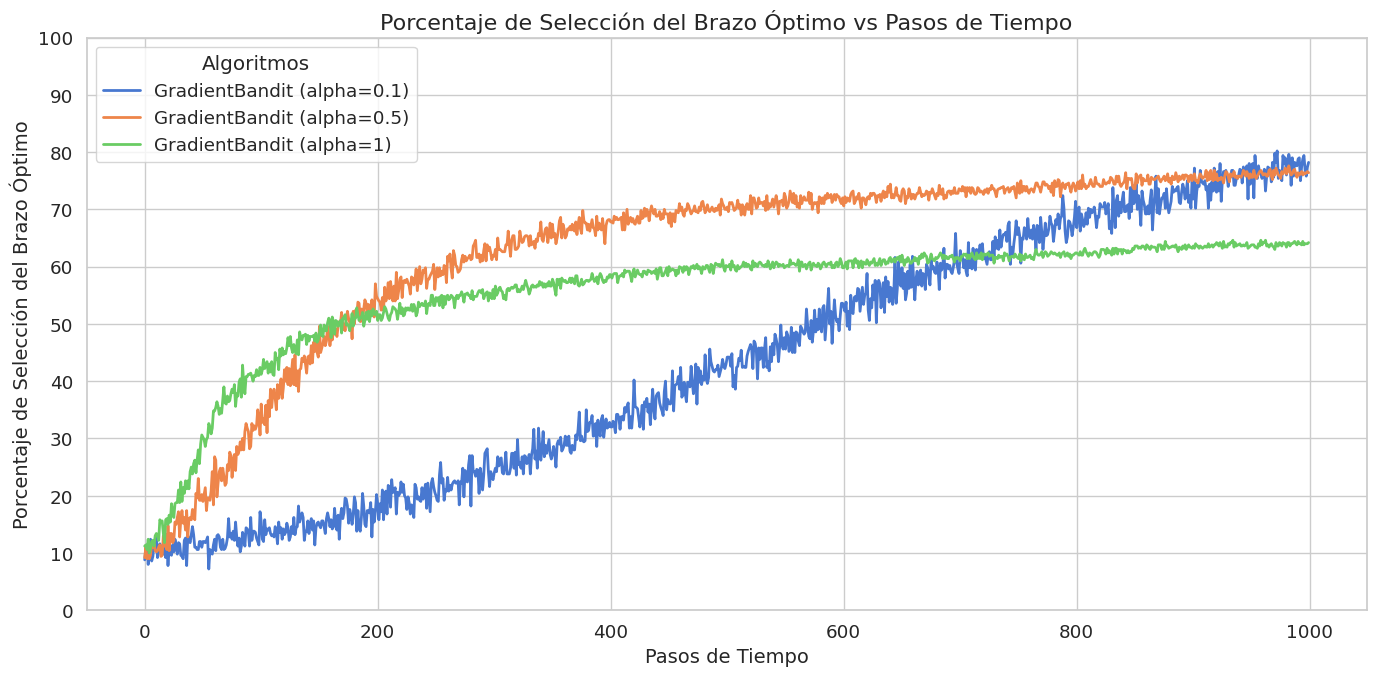

In [21]:
plot_optimal_selections(steps, optimal_selections, algorithms)

**Análisis**

El gráfico muestra el **porcentaje de selección del brazo óptimo** a lo largo del tiempo para diferentes valores de $\alpha$ en un bandido de 10 brazos con **recompensas Bernoulli**.  
Aquí, la recompensa de cada brazo es binaria ($0$ o $1$), lo que introduce mayor variabilidad en las observaciones en comparación con una distribución normal.

---

1. **Para $\alpha = 0.1$ (curva azul)**:  
   - El aprendizaje es **más lento** al inicio, pero el porcentaje de selección del brazo óptimo sigue aumentando progresivamente.  
   - Esto sugiere que el algoritmo está explorando más antes de estabilizarse en la explotación.  

2. **Para $\alpha = 0.5$ (curva naranja)**:  
   - Se observa **una convergencia más rápida** al mejor brazo en comparación con $\alpha = 0.1$.  
   - Sin embargo, el crecimiento se estabiliza alrededor del **75-80%**, lo que indica que aún hay cierta exploración residual.  

3. **Para $\alpha = 1$ (curva verde)**:  
   - Se alcanza un nivel de selección relativamente alto en las primeras etapas, pero luego se **estanca en torno al 65%**.  
   - Esto sugiere que el algoritmo está explorando demasiado y no se centra lo suficiente en explotar el mejor brazo.  

---

**Conclusión**
- **Para bandidos con recompensas Bernoulli, $\alpha = 0.5$ parece ser el mejor balance** entre exploración y explotación.  
- **$\alpha = 0.1$ es demasiado conservador**, lo que ralentiza la convergencia.  
- **$\alpha = 1$ explora demasiado y no logra una explotación óptima.**  
- **El mejor valor de $\alpha$ puede depender de la varianza en las recompensas, siendo $\alpha \approx 0.3 - 0.5$ una buena elección en este tipo de entornos.**


###### Rechazo promedio vs. Pasos de tiempo

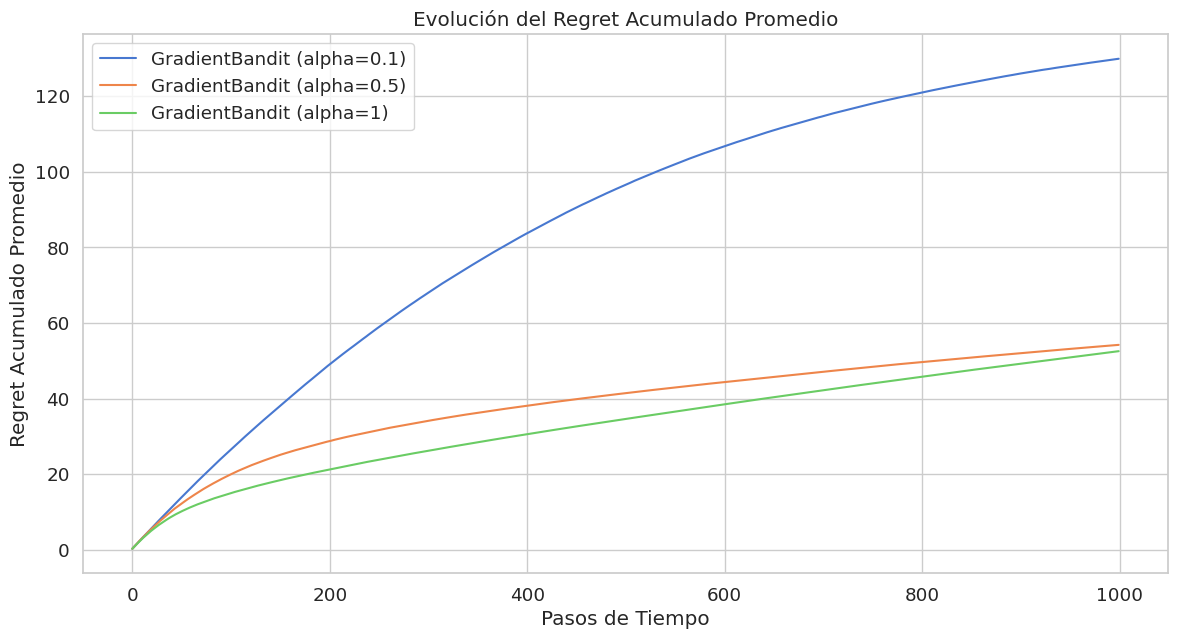

In [22]:
plot_regret(steps, regret, algorithms)

El gráfico muestra la **evolución del regret promedio** para distintos valores de $\alpha$ en el **Gradiente de Preferencias**, con un bandido de 10 brazos y recompensas Bernoulli.  

---

1. **Para $\alpha = 0.1$ (curva azul)**:  
   - **Mayor regret inicial y decrecimiento más lento**, lo que indica que el algoritmo **tarda más en explotar el mejor brazo**.  
   - La exploración prolongada provoca un regret más alto en las primeras etapas.  

2. **Para $\alpha = 0.5$ (curva naranja)**:  
   - **Balance óptimo** entre exploración y explotación.  
   - El regret disminuye rápidamente y se estabiliza en valores bajos, lo que sugiere una buena capacidad de identificación del mejor brazo.  

3. **Para $\alpha = 1$ (curva verde)**:  
   - **Menor regret promedio a lo largo del tiempo**, lo que indica que la exploración inicial es suficiente para encontrar el mejor brazo rápidamente.  
   - Sin embargo, este resultado podría deberse a que el algoritmo sigue explorando a lo largo del tiempo, evitando converger completamente en una única opción.  

---

**Conclusión**

**En bandidos Bernoulli, un $\alpha$ mayor puede ser preferible ($0.5 - 1.0$) en comparación con bandidos de distribución normal.**  

### Gradiente de preferencias - bandido con brazos de distribución binomial

In [23]:
# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k, n = 10, seed = SEED)) # Generar un bandido con k brazos de distribución Binomial
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [GradientBandit(k=k, alpha=0.1), GradientBandit(k=k, alpha=0.5), GradientBandit(k=k, alpha=1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
optimal_selections, regret = run_experiment_gradient(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=10, p=0.25), ArmBinomial(n=10, p=0.6), ArmBinomial(n=10, p=0.45), ArmBinomial(n=10, p=0.72), ArmBinomial(n=10, p=0.73), ArmBinomial(n=10, p=0.32), ArmBinomial(n=10, p=0.74), ArmBinomial(n=10, p=0.87), ArmBinomial(n=10, p=0.8), ArmBinomial(n=10, p=0.39)
Optimal arm: 8 with expected reward=8.7


#### Visualización de resultados

##### Porcentaje promedio de selección óptima vs. Pasos de tiempo

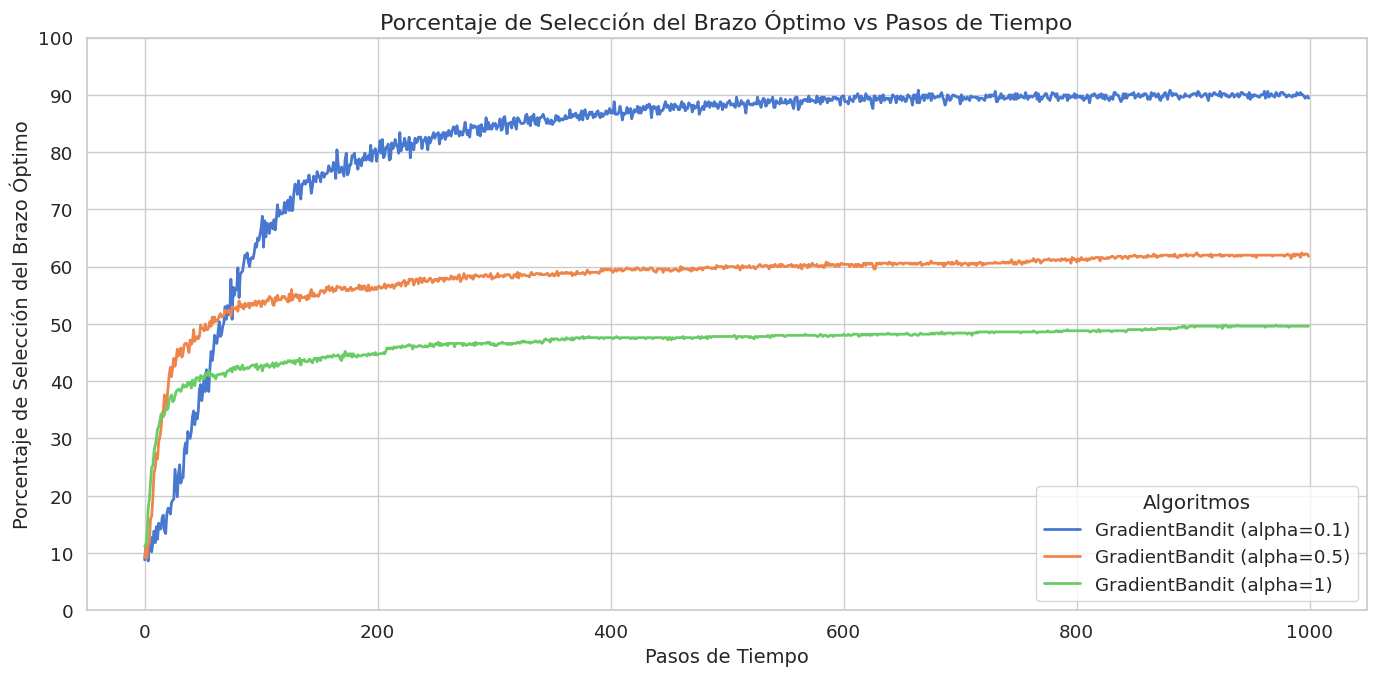

In [24]:
plot_optimal_selections(steps, optimal_selections, algorithms)

**Análisis**

El gráfico muestra el **porcentaje de selección del brazo óptimo** a lo largo del tiempo para el algoritmo de **Gradiente de Preferencias** en un **bandido con distribución Binomial ($ n = 10 $)**.  
Aquí, cada brazo devuelve recompensas en el rango $ [0, 10] $.

---

1. **Para $ \alpha = 0.1 $ (curva azul)**:  
   - Se observa **una rápida convergencia** y el algoritmo **explota agresivamente el mejor brazo** después de explorarlo.  
   - Se estabiliza alrededor del **90% de selección del brazo óptimo**, indicando un **buen balance** entre exploración y explotación.

2. **Para $ \alpha = 0.5 $ (curva naranja)**:  
   - El algoritmo explora más antes de estabilizarse, lo que **retrasa la explotación** del mejor brazo.  
   - La convergencia se da alrededor del **60%**, lo que sugiere que aún mantiene cierto nivel de exploración.

3. **Para $ \alpha = 1 $ (curva verde)**:  
   - Se observa una **exploración excesiva** a lo largo de todo el experimento.  
   - La selección del brazo óptimo se estabiliza en torno al **40%**, lo que indica que el algoritmo sigue probando otras acciones en lugar de explotar.

---

**Conclusión**

 **En bandidos con distribución binomial, valores bajos de $ \alpha $ ($ 0.1 - 0.3 $) favorecen una mejor explotación.**  


###### Rechazo promedio vs. Pasos de tiempo

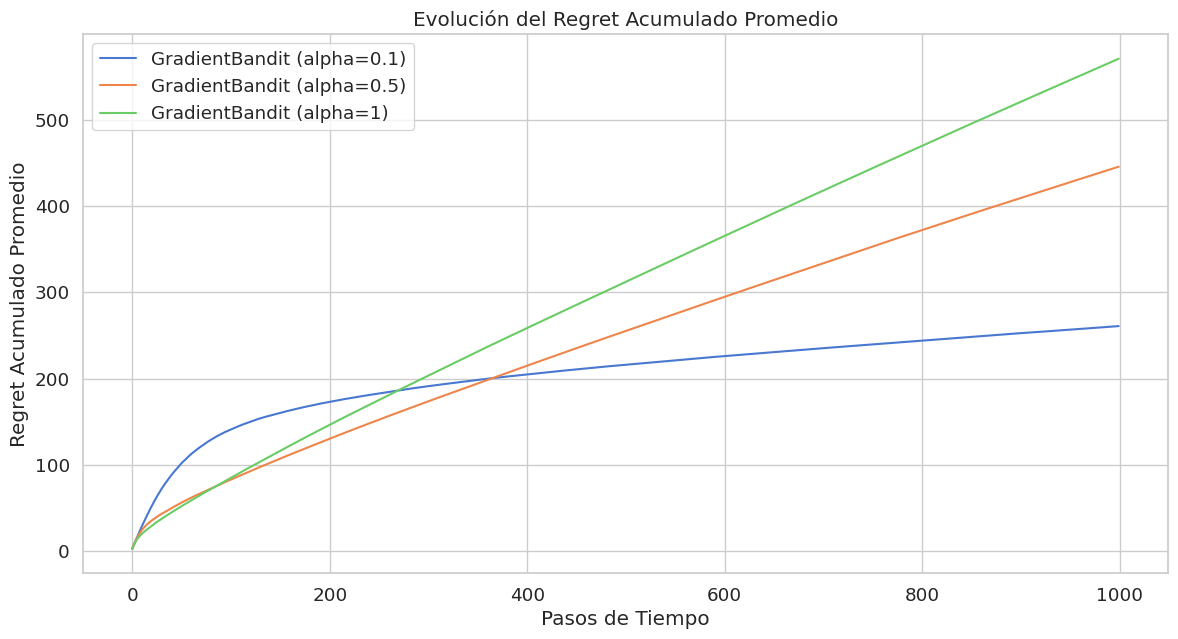

In [25]:
plot_regret(steps, regret, algorithms)

**Análisis**

El gráfico muestra la **evolución del regret acumulado** para distintos valores de $ \alpha $ en el **Gradiente de Preferencias**, con un bandido de 10 brazos y recompensas Binomiales ($ n = 10 $).  

---

1. **Para $ \alpha = 0.1 $ (curva azul)**:  
   - Se observa **una reducción más rápida del regret**, alcanzando los valores más bajos al final del experimento.  
   - Esto sugiere que el algoritmo encuentra el mejor brazo rápidamente y lo explota eficazmente.  

2. **Para $ \alpha = 0.5 $ (curva naranja)**:  
   - Presenta un **regret inicial más alto**, pero sigue una tendencia estable de reducción.  
   - La exploración adicional le permite evitar decisiones prematuras, pero a costa de un regret más alto en las primeras fases.  

3. **Para $ \alpha = 1 $ (curva verde)**:  
   - Se mantiene con el regret acumulado más alto a lo largo del tiempo, lo que indica que el algoritmo sigue explorando en exceso.  
   - La explotación del mejor brazo es más lenta, lo que impide alcanzar un regret bajo como en los otros casos.  

**Conclusión**

**En bandidos con distribución binomial, valores de $ \alpha $ en el rango $ 0.1 - 0.3 $ favorecen una mejor explotación y menor regret.**  

## Conclusiones finales

El **Gradiente de Preferencias** es un método efectivo, pero su desempeño depende de la elección de la tasa de aprendizaje ($ \alpha $) y de la distribución de recompensas.  
Para distribuciones **continuas o discretas con mayor granularidad** (Normal y Binomial), $ \alpha = 0.1 $ ofrece el mejor balance.  
En **recompensas binarias (Bernoulli), $ \alpha = 0.5 $ es una mejor opción** para evitar exploraciones insuficientes.  
En general, **valores altos de $ \alpha $ ($ \geq 1 $) deben evitarse**, ya que impiden que el algoritmo se estabilice en el mejor brazo.